In [1]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/p(z | X)/ablation-loss-fn/2024-11-28_09-11-33_f1_direct_regression/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss
0,0.0,NaN,0,6.682022,NaN
1,1.0,NaN,0,9.661362,NaN
2,2.0,NaN,0,5.408042,NaN
3,3.0,NaN,0,8.374090,NaN
4,4.0,NaN,0,2.835927,NaN


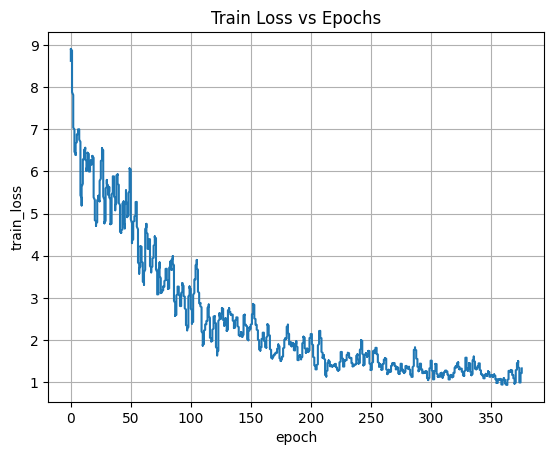

In [2]:
from scipy.ndimage import gaussian_filter1d

SIGMA = 10

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

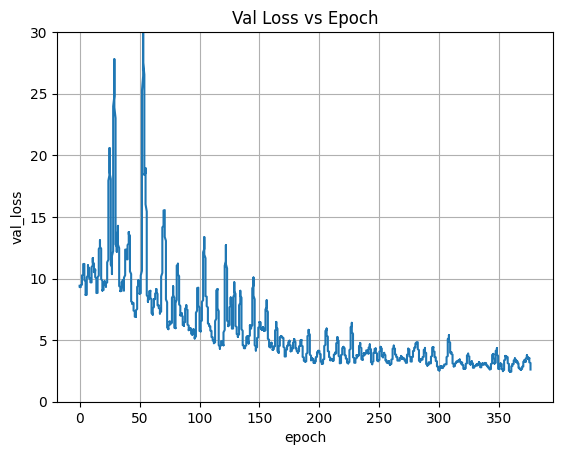

In [3]:
# plot val_loss vs. global_val_step
_df = df[df["global_val_step"].notna()]
val_steps = _df["epoch"]
val_losses = _df["val_loss"]
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# plt.plot(val_steps, val_losses)
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.ylim(0, 30)
plt.title("Val Loss vs Epoch")
plt.grid()
plt.show()

In [4]:
_df["val_loss"][-10: ]

12053    2.077566
12054    2.807435
12055    2.520429
12056    1.992711
12057    2.193320
12058    2.890361
12059    2.298881
12060    1.922427
12061    2.410735
12062    2.499571
Name: val_loss, dtype: float64